# Exploratory data analysis (EDA) sandbox using IMDb movies database

Import nescessary modules and load dataset to `pandas.DataFrame`

In [101]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

'''
Datasets for sandbox were downloaded from kaggle
'''

df = pd.read_csv('imdb_top_1000.csv')

Print info about dataset.

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 520.0 KB


TODO:
* change column name `Series_Title -> Title`,
* resolve problems with null values,
* gross `str -> int`.

In [103]:
print('----- Gross style -----')
print(df['Gross'].head())
print('\n----- Certificate values -----')
print(df['Certificate'].unique())
print('\n----- Genres style -----')
print(df['Genre'].head())

----- Gross style -----
0     28,341,469
1    134,966,411
2    534,858,444
3     57,300,000
4      4,360,000
Name: Gross, dtype: str

----- Certificate values -----
<ArrowStringArray>
[       'A',       'UA',        'U',    'PG-13',        'R',        nan,
       'PG',        'G',   'Passed',    'TV-14',       '16',    'TV-MA',
  'Unrated',       'GP', 'Approved',    'TV-PG',      'U/A']
Length: 17, dtype: str

----- Genres style -----
0                   Drama
1            Crime, Drama
2    Action, Crime, Drama
3            Crime, Drama
4            Crime, Drama
Name: Genre, dtype: str


In [104]:
df.replace({
    'Certificate': {np.nan: 'Unknown'},
    'Meta_score': {np.nan: 0},
    'Gross': {np.nan: '0'},
}, inplace=True)
if df['Gross'].dtype == 'str':
    df['Gross'] = df['Gross'].apply(lambda x: int(x.replace(',', '')))

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    1000 non-null   str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   int64  
dtypes: float64(2), int64(2), str(12)
memory usage: 512.8 KB
None


In [105]:
df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
IMDB_Rating,1000.0,7.949300e+00,2.754912e-01,7.6,7.70,7.9,8.10,9.3
Meta_score,1000.0,6.573000e+01,3.057021e+01,0.0,63.00,76.0,85.25,100.0
No_of_Votes,1000.0,2.736929e+05,3.273727e+05,25088.0,55526.25,138548.5,374161.25,2343110.0
Gross,1000.0,5.653688e+07,1.032382e+08,0.0,445709.75,10702751.5,61539891.25,936662225.0


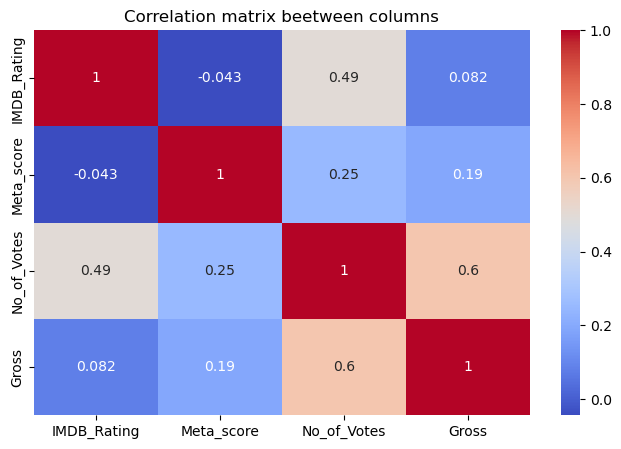

In [106]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.show()

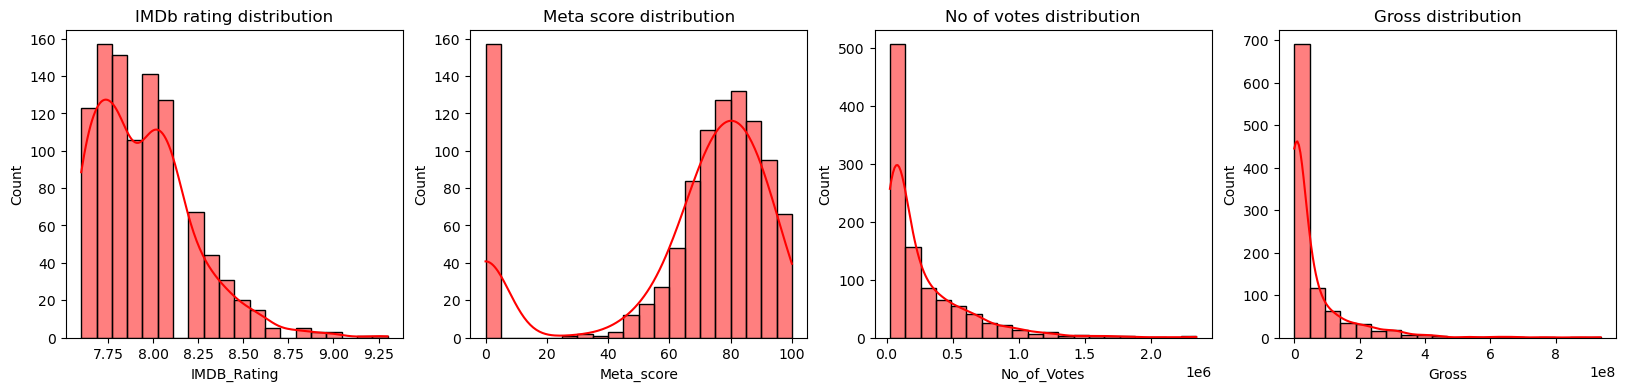

In [107]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='red')
plt.title('IMDb rating distribution')
plt.subplot(142)
sns.histplot(df['Meta_score'], bins=20, kde=True, color='red')
plt.title('Meta score distribution')
plt.subplot(143)
sns.histplot(df['No_of_Votes'], bins=20, kde=True, color='red')
plt.title('No of votes distribution')
plt.subplot(144)
sns.histplot(df['Gross'], bins=20, kde=True, color='red')
plt.title('Gross distribution')
plt.show()

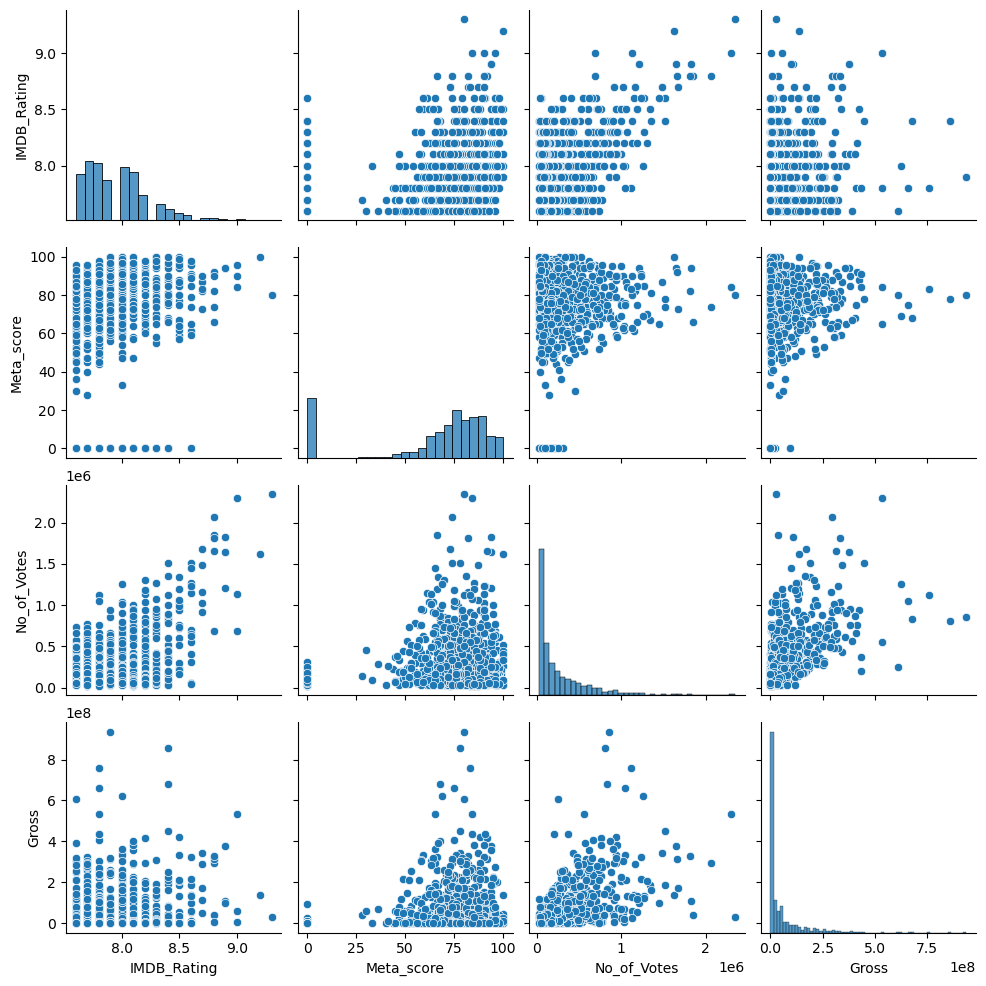

In [108]:
sns.pairplot(df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']])

Rows with 0 values in `Meta_score`, `No_of_votes`, and `Gross` should be removed 

In [109]:
df = df[df['Meta_score'] > 0]
df = df[df['Gross'] > 0]

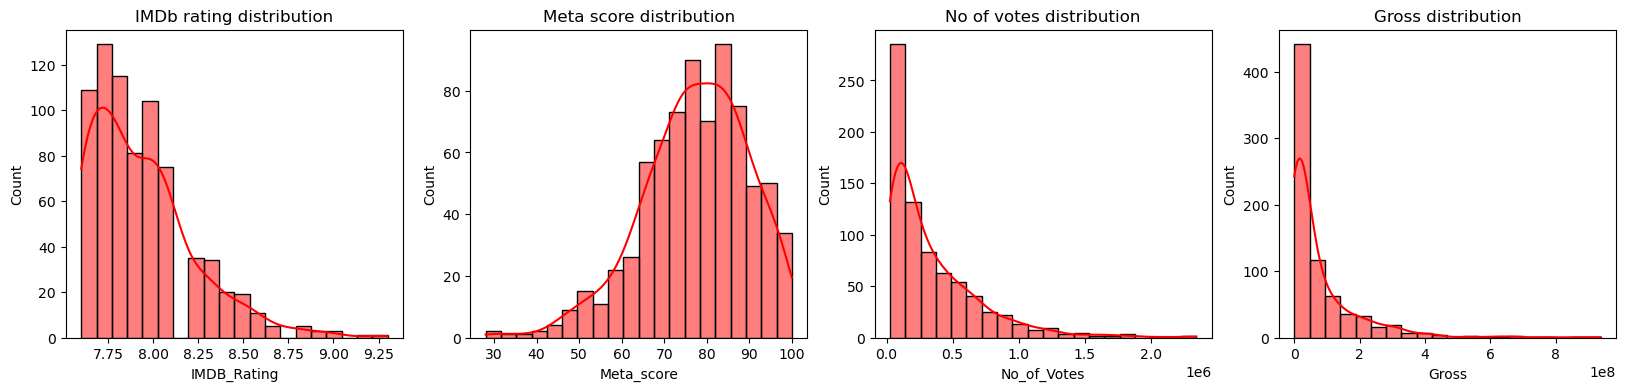

In [110]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='red')
plt.title('IMDb rating distribution')
plt.subplot(142)
sns.histplot(df['Meta_score'], bins=20, kde=True, color='red')
plt.title('Meta score distribution')
plt.subplot(143)
sns.histplot(df['No_of_Votes'], bins=20, kde=True, color='red')
plt.title('No of votes distribution')
plt.subplot(144)
sns.histplot(df['Gross'], bins=20, kde=True, color='red')
plt.title('Gross distribution')
plt.show()

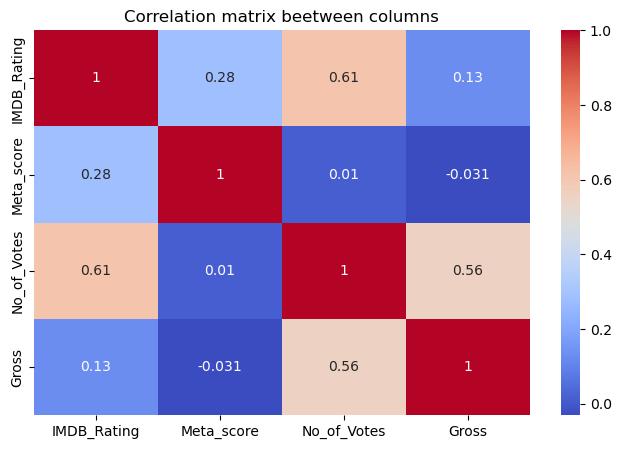

In [111]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.show()

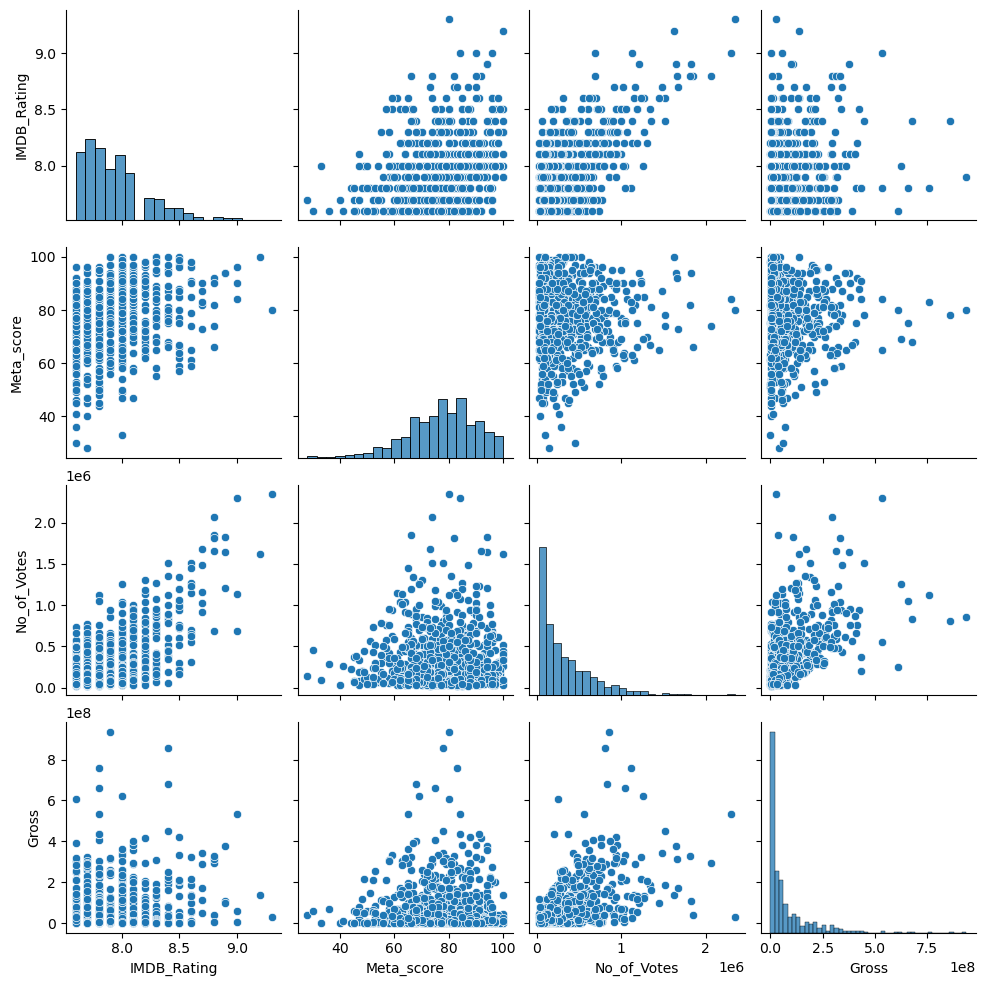

In [112]:
sns.pairplot(df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']])